# Estructura del colab

En este colab se encuentra todo el codigo que hemos desarollado para hacer este proyecto. Lo hemos estrucuturado de las siguiente manera.

(Nosotros no hemos ejecturado los entrenamientos en colab, ya que era muy lento. Lo hemos hecho en un ordenador local con una GPU. De todas formas, todos los entrenamientos deberian funcionar en el colab)

0. Preparacion del dataset
1. Desarollo del baseline (ResNet)
2. Modelo RT-DERT de ultralytics
3. RT-DERT desde cero simplificado

## Dataset

Lo primero de todo es descargar, descomprimir y estructurar el dataset.

In [ ]:
# Descargar imagenes y anotaciones
# !wget https://datasets.d2.mpi-inf.mpg.de/andriluka14cvpr/mpii_human_pose_v1.tar.gz
!wget https://datasets.d2.mpi-inf.mpg.de/andriluka14cvpr/mpii_human_pose_v1_u12_2.zip


--2026-01-15 19:12:47--  https://datasets.d2.mpi-inf.mpg.de/andriluka14cvpr/mpii_human_pose_v1_u12_2.zip
Resolving datasets.d2.mpi-inf.mpg.de (datasets.d2.mpi-inf.mpg.de)... 139.19.206.177
Connecting to datasets.d2.mpi-inf.mpg.de (datasets.d2.mpi-inf.mpg.de)|139.19.206.177|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 12340483 (12M) [application/zip]
Saving to: ‘mpii_human_pose_v1_u12_2.zip’

mpii_human_pose_v1_ 100%[===================>]  11.77M  9.94MB/s    in 1.2s    

2026-01-15 19:12:49 (9.94 MB/s) - ‘mpii_human_pose_v1_u12_2.zip’ saved [12340483/12340483]



In [ ]:
!mkdir -p dataset/
# Descomprimir imágenes
!tar -xvf mpii_human_pose_v1.tar.gz dataset/ -C dataset/

# Descomprimir anotaciones
!unzip mpii_human_pose_v1_u12_2.zip -d dataset/

tar: dataset: Not found in archive
tar: Exiting with failure status due to previous errors
Archive:  mpii_human_pose_v1_u12_2.zip
   creating: dataset/mpii_human_pose_v1_u12_2/
  inflating: dataset/mpii_human_pose_v1_u12_2/bsd.txt  
  inflating: dataset/mpii_human_pose_v1_u12_2/mpii_human_pose_v1_u12_1.mat  
  inflating: dataset/mpii_human_pose_v1_u12_2/README.md  


In [ ]:
import scipy.io
import os
import shutil
import cv2
import numpy as np
import random
import yaml
import matplotlib.pyplot as plt
import numpy as np

from tqdm import tqdm

# --- CONFIGURATION ---
MAT_FILE = 'mpii_human_pose_v1_u12_2/mpii_human_pose_v1_u12_1.mat'
SOURCE_IMG_DIR = 'images'   # Where the raw extracted images are
DATASET_DIR = 'dataset'     # Where we will build the organized dataset
SPLIT_RATIO = 0.9           # 90% Train, 10% Validation
# ---------------------

def setup_directories():
    """Creates the standard YOLO/RT-DETR folder structure."""
    if os.path.exists(DATASET_DIR):
        print(f"Warning: '{DATASET_DIR}' already exists. Merging/Overwriting...")

    for split in ['train', 'val']:
        os.makedirs(os.path.join(DATASET_DIR, 'images', split), exist_ok=True)
        os.makedirs(os.path.join(DATASET_DIR, 'labels', split), exist_ok=True)

def get_bbox(rect, img_width, img_height):
    """Extracts and normalizes head bbox. Returns None if invalid/bystander."""

    # FILTER: "Main Activity" check.
    # If 'annopoints' (body joints) are missing/empty, it's a bystander.
    if not hasattr(rect, 'annopoints') or np.all(rect.annopoints == []):
        return None

    # Check if head coordinates exist
    if not (hasattr(rect, 'x1') and hasattr(rect, 'y1') and
            hasattr(rect, 'x2') and hasattr(rect, 'y2')):
        return None

    try:
        # Extract raw coordinates (handling numpy scalar weirdness)
        x1 = float(rect.x1) if np.ndim(rect.x1) == 0 else float(rect.x1.item())
        y1 = float(rect.y1) if np.ndim(rect.y1) == 0 else float(rect.y1.item())
        x2 = float(rect.x2) if np.ndim(rect.x2) == 0 else float(rect.x2.item())
        y2 = float(rect.y2) if np.ndim(rect.y2) == 0 else float(rect.y2.item())

        # Calculate YOLO center-x, center-y, width, height (Normalized)
        w = x2 - x1
        h = y2 - y1
        cx = x1 + (w / 2)
        cy = y1 + (h / 2)

        norm_cx = cx / img_width
        norm_cy = cy / img_height
        norm_w = w / img_width
        norm_h = h / img_height

        # Clip values to ensure they stay within [0, 1]
        norm_cx = max(0.0, min(1.0, norm_cx))
        norm_cy = max(0.0, min(1.0, norm_cy))
        norm_w = max(0.0, min(1.0, norm_w))
        norm_h = max(0.0, min(1.0, norm_h))

        return f"0 {norm_cx:.6f} {norm_cy:.6f} {norm_w:.6f} {norm_h:.6f}"
    except:
        return None

def create_yaml_config():
    """Generates the .yaml file for RT-DETR."""
    config = {
        'path': os.path.abspath(DATASET_DIR),
        'train': 'images/train',
        'val': 'images/val',
        'names': {0: 'main_head'}
    }

    yaml_path = os.path.join(DATASET_DIR, 'mpii_heads.yaml')
    with open(yaml_path, 'w') as f:
        yaml.dump(config, f, sort_keys=False)

    return yaml_path

def main():
    setup_directories()

    print(f"Loading {MAT_FILE}... (This usually takes 30-60 seconds)")
    mat = scipy.io.loadmat(MAT_FILE, struct_as_record=False, squeeze_me=True)
    data = mat['RELEASE']
    annolist = data.annolist
    img_train_flags = data.img_train

    # Collect valid samples
    valid_samples = []

    print("Parsing annotations...")
    for idx, annotation in enumerate(tqdm(annolist)):
        # Skip official test set (no labels available)
        if img_train_flags[idx] == 0:
            continue

        try:
            image_name = annotation.image.name
            full_img_path = os.path.join(SOURCE_IMG_DIR, image_name)

            # Check if image exists
            if not os.path.exists(full_img_path):
                continue

            # We need dimensions. cv2.imread is slow, so we only read if needed.
            # But we need dimensions to normalize.
            img = cv2.imread(full_img_path)
            if img is None: continue
            h_img, w_img = img.shape[:2]

            rects = annotation.annorect
            if not isinstance(rects, np.ndarray):
                rects = [rects]

            labels = []
            for rect in rects:
                yolo_line = get_bbox(rect, w_img, h_img)
                if yolo_line:
                    labels.append(yolo_line)

            # Only keep image if we found a "Main Actor" head
            if labels:
                valid_samples.append({
                    'name': image_name,
                    'path': full_img_path,
                    'labels': labels
                })

        except Exception as e:
            continue

    print(f"Found {len(valid_samples)} valid images with 'Main Actor' heads.")

    # Shuffle and Split
    random.seed(42)
    random.shuffle(valid_samples)
    split_idx = int(len(valid_samples) * SPLIT_RATIO)
    train_set = valid_samples[:split_idx]
    val_set = valid_samples[split_idx:]

    print("Copying files and writing labels...")

    def process_set(dataset, split_name):
        for sample in tqdm(dataset, desc=f"Processing {split_name}"):
            # 1. Copy Image
            dst_img_path = os.path.join(DATASET_DIR, 'images', split_name, sample['name'])
            shutil.copy2(sample['path'], dst_img_path)

            # 2. Write Label File
            txt_name = sample['name'].replace('.jpg', '.txt')
            dst_label_path = os.path.join(DATASET_DIR, 'labels', split_name, txt_name)
            with open(dst_label_path, 'w') as f:
                f.write('\n'.join(sample['labels']))

    process_set(train_set, 'train')
    process_set(val_set, 'val')

    yaml_path = create_yaml_config()

    print("\n" + "="*50)
    print("SUCCESS!")
    print(f"Dataset ready at: {os.path.abspath(DATASET_DIR)}")
    print(f"Config file created at: {yaml_path}")
    print("="*50)
    print("Use this command to train:")
    print(f"model = RTDETR('rtdetr-l.yaml')")
    print(f"model.train(data='{yaml_path}', epochs=300, device=0)")

if __name__ == "__main__":
    main()


Loading mpii_human_pose_v1_u12_2/mpii_human_pose_v1_u12_1.mat... (This usually takes 30-60 seconds)


FileNotFoundError: [Errno 2] No such file or directory: 'mpii_human_pose_v1_u12_2/mpii_human_pose_v1_u12_1.mat'

## Desarollo de los modelos

Una vez que ya tenemos el dataset listo, vamos a empezar a desarollar los modelos

Primero hacemos varios imports y definimos funciones auxiliares que vayamos a necesitar despues.

**VAMOS A GUARDAR EL DATASET EN NUESTRO DRIVE, Y LO OBTENDREMOS DE AHÍ**

In [ ]:
# Instalación de dependencias
!pip install ultralytics opencv-python scipy torchmetrics

# Montar Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Imports generales
import os
import cv2
import numpy as np
import scipy.io as sio
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import numpy as np

from torchmetrics.detection.mean_ap import MeanAveragePrecision
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms



Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


### Configuración de rutas y dispositivo

Este subbloque define una única vez las rutas que se usarán en todo el notebook y el dispositivo (CPU/GPU).

In [ ]:
# =====================================================
# RUTAS DEL PROYECTO Y DISPOSITIVO
# =====================================================

#PROJECT_ROOT = "/content/drive/MyDrive/Colab Notebooks/trabajoAARN"
PROJECT_ROOT = "."


# Dataset en formato YOLO (ya procesado)
DATASET_ROOT = f"{PROJECT_ROOT}/dataset"
#
IMAGES_DIR = f"{DATASET_ROOT}/images"
LABELS_DIR = f"{DATASET_ROOT}/labels"

TRAIN_IMAGES_DIR = f"{DATASET_ROOT}/images/train"
VAL_IMAGES_DIR   = f"{DATASET_ROOT}/images/val"

TRAIN_LABELS_DIR = f"{DATASET_ROOT}/labels/train"
VAL_LABELS_DIR   = f"{DATASET_ROOT}/labels/val"

# Dispositivo
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Dispositivo:", DEVICE)


Dispositivo: cuda


### Función para extraer bounding boxes de cabeza

MPII proporciona directamente la bounding box de la cabeza para cada persona anotada.

In [ ]:
# =====================================================
# EXTRACCIÓN DE HEAD BOUNDING BOX
# =====================================================

def get_head_bboxes(ann):
    """
    Devuelve una lista de bounding boxes de cabeza
    Cada box es (x1, y1, x2, y2)
    """
    boxes = []

    if not hasattr(ann, "annorect"):
        return boxes

    rects = ann.annorect
    if not isinstance(rects, list):
        rects = [rects]

    for r in rects:
        if hasattr(r, "x1") and hasattr(r, "x2"):
            boxes.append((int(r.x1), int(r.y1),
                          int(r.x2), int(r.y2)))

    return boxes


##  1. Desarollo del baseline (ResNet)

Para defiinir un baseline vamos a entrenar el dataset con el modelo por defecto para esta tarea, para luego poder compararlo con el modelo de estado del arte

###1.1 Dataset y DataLoader (multi-head)

El dataset devuelve: la imagen y todas las bounding boxes asociadas a esa imagen.
La selección de una sola cabeza NO se hace aquí, sino en el training loop (esto se hace para poder reutilizar el codigo para cuando si vayamos a predecir multiples cabezas)

In [ ]:
# =====================================================
# DATASET PARA RESNET (MULTI-HEAD)
# =====================================================

class MPIIHeadDataset(Dataset):
    def __init__(self, images_dir, labels_dir, transform=None):
        self.images_dir = images_dir
        self.labels_dir = labels_dir
        self.transform = transform

        self.image_files = [
            f for f in os.listdir(images_dir)
            if f.endswith(".jpg")
        ]

    def __len__(self):
        return len(self.image_files)

    def __getitem__(self, idx):
        img_name = self.image_files[idx]
        img_path = os.path.join(self.images_dir, img_name)

        label_path = os.path.join(
            self.labels_dir,
            img_name.replace(".jpg", ".txt")
        )

        image = cv2.imread(img_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        boxes = []
        if os.path.exists(label_path):
            with open(label_path, "r") as f:
                for line in f:
                    _, x, y, w, h = map(float, line.split())
                    boxes.append([x, y, w, h])

        boxes = torch.tensor(boxes, dtype=torch.float32)

        if self.transform:
            image = self.transform(image)

        return image, boxes


###1.2 Transformaciones y collate_fn

Como cada imagen puede tener un número distinto de cabezas, usamos un
collate_fn personalizado para evitar errores de batching.

In [ ]:
# =====================================================
# TRANSFORMACIONES Y COLLATE FUNCTION
# =====================================================

transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])


def collate_fn(batch):
    images = []
    boxes = []

    for img, b in batch:
        images.append(img)
        boxes.append(b)

    images = torch.stack(images, dim=0)
    return images, boxes


### 1.3 DataLoader de entrenamiento

In [ ]:
# =====================================================
# DATALOADER
# =====================================================

train_dataset = MPIIHeadDataset(
    images_dir=TRAIN_IMAGES_DIR,
    labels_dir=TRAIN_LABELS_DIR,
    transform=transform
)

val_dataset = MPIIHeadDataset(
    images_dir=VAL_IMAGES_DIR,
    labels_dir=VAL_LABELS_DIR,
    transform=transform
)

train_loader = DataLoader(
    train_dataset,
    batch_size=256,
    shuffle=True,
    drop_last=True,
    collate_fn=collate_fn
)

val_loader = DataLoader(
    val_dataset,
    batch_size=256,
    shuffle=False, # Usually False for validation to keep order constant
    drop_last=True,
    collate_fn=collate_fn
)

### 1.4 Arquitectura ResNet (regresión de bounding box)

Se utiliza ResNet18 preentrenada como extractor de características y se adapta
la última capa para predecir:

In [ ]:
# =====================================================
# MODELO RESNET PARA DETECCIÓN DE CABEZA
# =====================================================

class ResNetBBox(nn.Module):
    def __init__(self):
        super().__init__()

        self.backbone = models.resnet18(
            weights=models.ResNet18_Weights.DEFAULT
        )

        self.backbone.fc = nn.Sequential(
            nn.Linear(self.backbone.fc.in_features, 128),
            nn.ReLU(),
            nn.Linear(128, 4),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.backbone(x)


resnet_model = ResNetBBox().to(DEVICE)


### 1.5 Selección de una sola cabeza (decisión de diseño)

Durante el entrenamiento se selecciona una única cabeza por imagen.
El criterio usado es la cabeza de mayor área, que suele corresponder
a la persona principal.

In [ ]:
def select_one_head(boxes):
    """
    boxes: Tensor [N, 4] -> (x, y, w, h)
    Selecciona la cabeza con mayor área para el entrenamiento.
    """
    if boxes.numel() == 0:
        return torch.zeros(4)

    areas = boxes[:, 2] * boxes[:, 3]
    idx = torch.argmax(areas)
    return boxes[idx]

def convert_to_xyxy(box_tensor, width, height):
    """
    Convierte Normalized (cx, cy, w, h) -> Absolute (x1, y1, x2, y2)
    Necesario para torchmetrics.
    """

    # Asegurar dimensión [N, 4]
    if box_tensor.ndim == 1:
        box_tensor = box_tensor.unsqueeze(0)

    cx, cy, w, h = box_tensor.unbind(-1)

    # Centro a Esquinas
    x1 = cx - 0.5 * w
    y1 = cy - 0.5 * h
    x2 = cx + 0.5 * w
    y2 = cy + 0.5 * h

    # Escalar a pixeles
    x1 = x1 * width
    y1 = y1 * height
    x2 = x2 * width
    y2 = y2 * height

    return torch.stack([x1, y1, x2, y2], dim=-1)


### 1.6 Entrenamiento del ResNet

Se formula la detección como un problema de regresión supervisada y se utiliza
MSE como función de pérdida.

In [ ]:

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(resnet_model.parameters(), lr=1e-4)

num_epochs = 100
best_map = 0.0
save_path = "checkpoints_resnet/"
os.makedirs(save_path, exist_ok=True)

# Métrica mAP (COCO-style)
metric = MeanAveragePrecision(iou_type="bbox")

print(f"Starting ResNet training on {DEVICE}...")

for epoch in range(num_epochs):

    # -----------------------------
    # 1. TRAIN LOOP (TU CÓDIGO)
    # -----------------------------
    resnet_model.train()
    total_loss = 0.0

    for images, boxes in train_loader:
        images = images.to(DEVICE)

        targets = []
        for b in boxes:
            targets.append(select_one_head(b))

        targets = torch.stack(targets).to(DEVICE)

        preds = resnet_model(images)
        loss = criterion(preds, targets)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        print(total_loss)
    avg_loss = total_loss / len(train_loader)

    # -----------------------------
    # 2. VALIDATION LOOP (mAP)
    # -----------------------------
    resnet_model.eval()
    metric.reset()

    with torch.no_grad():
        for images, boxes_list in val_loader:
            images = images.to(DEVICE)

            raw_preds = resnet_model(images)  # [B, 4]
            formatted_preds = []
            formatted_targets = []

            img_h, img_w = 224, 224  # por el resize

            for i in range(len(images)):
                # --- Predicción (UNA caja) ---
                pred_xyxy = convert_to_xyxy(raw_preds[i], img_w, img_h)

                formatted_preds.append({
                    "boxes": pred_xyxy,
                    "scores": torch.tensor([1.0], device=DEVICE),
                    "labels": torch.tensor([0], device=DEVICE)
                })

                # --- Ground Truth (TODAS las cabezas) ---
                gt_boxes = boxes_list[i].to(DEVICE)

                if gt_boxes.numel() > 0:
                    gt_xyxy = convert_to_xyxy(gt_boxes, img_w, img_h)
                    gt_labels = torch.zeros(
                        gt_boxes.shape[0], dtype=torch.long, device=DEVICE
                    )
                else:
                    gt_xyxy = torch.empty((0, 4), device=DEVICE)
                    gt_labels = torch.empty((0,), dtype=torch.long, device=DEVICE)

                formatted_targets.append({
                    "boxes": gt_xyxy,
                    "labels": gt_labels
                })

            metric.update(formatted_preds, formatted_targets)

    metrics = metric.compute()
    map_50 = metrics["map_50"]
    map_50_95 = metrics["map"]

    # -----------------------------
    # 3. STATS & SAVING
    # -----------------------------
    print(
        f"[ResNet] Epoch [{epoch+1}/{num_epochs}] "
        f"| Loss: {avg_loss:.4f} "
        f"| mAP@50: {map_50:.4f} "
        f"| mAP@50-95: {map_50_95:.4f}"
    )

    if map_50 > best_map:
        best_map = map_50
        torch.save(resnet_model.state_dict(), f"{save_path}/best.pt")
        print(f"--> Saved new best model (mAP@50: {best_map:.4f})")

    torch.save(resnet_model.state_dict(), f"{save_path}/last.pt")

print("ResNet training finished.")


Starting ResNet training on cuda...
0.05827523395419121
0.10843044146895409


KeyboardInterrupt: 

### 1.7 Para cargar los pesos preentrenados

Usar fichero de pesos adjuntos, en la carpeta modelos "resnet.pt"

In [ ]:
resnet_model = ResNetBBox().to(DEVICE)

resnet_checkpoint_path = "/content/drive/MyDrive/resnet.pt"

state_dict = torch.load(resnet_checkpoint_path, map_location=DEVICE)
resnet_model.load_state_dict(state_dict)

resnet_model.eval()

print("ResNet weights loaded correctly")


ResNet weights loaded correctly


### 1.8 Visualización de algun ejemplo predicho

In [ ]:
def visualize_prediction(model, dataset, index):
    model.eval()

    image_tensor, boxes = dataset[index]

    img_path = os.path.join(dataset.images_dir, dataset.image_files[index])
    image = cv2.imread(img_path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    img_h, img_w, _ = image.shape

    gt_box = select_one_head(boxes)

    if gt_box is not None and gt_box.numel() > 0:
        gt_xyxy = convert_to_xyxy(gt_box, img_w, img_h)[0]
        gx1, gy1, gx2, gy2 = gt_xyxy.int().tolist()

        cv2.rectangle(
            image,
            (gx1, gy1),
            (gx2, gy2),
            (0, 255, 0),
            2
        )

    with torch.no_grad():
        pred = model(image_tensor.unsqueeze(0).to(DEVICE))[0].cpu()

    pred_xyxy = convert_to_xyxy(pred, img_w, img_h)[0]
    px1, py1, px2, py2 = pred_xyxy.int().tolist()

    cv2.rectangle(
        image,
        (px1, py1),
        (px2, py2),
        (255, 0, 0),
        2
    )


    plt.figure(figsize=(6, 6))
    plt.imshow(image)
    plt.axis("off")
    plt.title("ResNet | Verde: GT | Rojo: Predicción")
    plt.show()


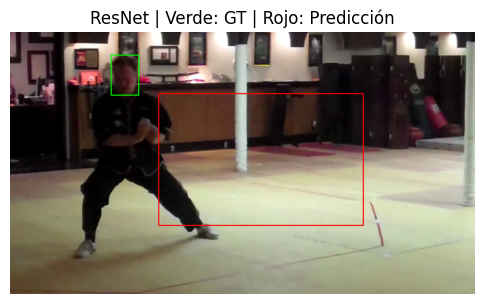

In [ ]:
visualize_prediction(resnet_model, train_dataset, index=770)


##2. Modelo RT-DERT de ultralytics

Ahora que ya tenemos un baseline, vamos a empezar a entrenar un modelo un poco mas avanzado.

Para facilitar el desarollo, vamos a usar la implementacion proporcionada por ultralytics.

Antes de entrenar el modelo desde cero, vamos a hacer un fine tunning del modelo pre-entrenado para asegurarnos de que todo funciona y el modelo aprende correctamente.

In [ ]:
# =====================================================
# DATASET YAML PARA RT-DETR
# =====================================================

dataset_yaml_path = f"{DATASET_ROOT}/mpii_heads.yaml"

with open(dataset_yaml_path, "w") as f:
    f.write(f"""
path: {DATASET_ROOT}
train: images/train
val: images/val

names:
  0: head
""")

print("dataset.yaml creado en:", dataset_yaml_path)


Ahora elegimos los pesos "rtdeter-l.pt" para ser usados. Estos son pesos pre-entrenados

Para luego hacer el entrenamiento desde cero, solo tenemos que cambiar la linea que carga los pesos y poner "rtdetr-l.yaml"



In [ ]:
from ultralytics import RTDETR

rtdetr_pretrained = RTDETR("rtdetr-l.pt")
# rtdetr_pretrained = RTDETR("rtdetr-l.yaml") # Para entrenar desde 0


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [ ]:
rtdetr_pretrained.train(
    data=dataset_yaml_path,
    epochs=20,
    imgsz=640,
    batch=4,
    device=0 if DEVICE == "cuda" else "cpu"
)


Ultralytics 8.4.2 🚀 Python-3.12.12 torch-2.9.0+cpu CPU (Intel Xeon CPU @ 2.20GHz)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=4, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/Colab Notebooks/trabajoAARN/dataset/mpii_heads.yaml, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=20, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=rtdetr-l.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=Tr

### 2.2 Para visualizar
En el zip adjunto a la entrega, dentro de la carpeta pesos_modelos, adjuntamos los pesos aprendidos para que se pueda visualizar.
-Para rt detr entrenado desde 0 usar best_desde_0.pt
-Para rt detr preentrenado usar best_pree.pt

In [ ]:

# Load model
model = RTDETR('./best_full.pt') #mediante esto cargamos los pesos que hemos entrenado para el modelo desde 0

# Run inference
results = model(f'{VAL_IMAGES_DIR}/000135363.jpg')

# Visualize
for result in results:
    result.show()  # Opens a window
    result.save(filename='result.jpg')  # Saves to disk

UnpicklingError: invalid load key, 'E'.

## 3. RT-DERT desde cero simplificado

### 3.1 imports necesarios


In [ ]:

import torch.nn.functional as F
from scipy.optimize import linear_sum_assignment


### 3.2 Configuración del RT-DETR propio

In [ ]:
# Hyperparameters
NUM_CLASSES = 1      # Only "Head"
NUM_QUERIES = 20     # Max objects to detect per image
HIDDEN_DIM = 256     # Transformer dimension
LR = 1e-4
LR_BACKBONE = 1e-5
WEIGHT_DECAY = 1e-4
BATCH_SIZE = 16      # Smaller batch size for Transformer
NUM_EPOCHS = 100


### 3.3 Utilidades para el bounding box

In [ ]:
def box_cxcywh_to_xyxy(x):
    x_c, y_c, w, h = x.unbind(-1)
    b = [(x_c - 0.5 * w), (y_c - 0.5 * h),
         (x_c + 0.5 * w), (y_c + 0.5 * h)]
    return torch.stack(b, dim=-1)

def box_iou(boxes1, boxes2):
    area1 = (boxes1[:, 2] - boxes1[:, 0]) * (boxes1[:, 3] - boxes1[:, 1])
    area2 = (boxes2[:, 2] - boxes2[:, 0]) * (boxes2[:, 3] - boxes2[:, 1])

    lt = torch.max(boxes1[:, None, :2], boxes2[:, :2])
    rb = torch.min(boxes1[:, None, 2:], boxes2[:, 2:])
    wh = (rb - lt).clamp(min=0)
    inter = wh[:, :, 0] * wh[:, :, 1]
    union = area1[:, None] + area2 - inter
    return inter / union, union

def generalized_box_iou(boxes1, boxes2):
    # Generalized IoU (GIoU) for loss
    iou, union = box_iou(boxes1, boxes2)
    lt = torch.min(boxes1[:, None, :2], boxes2[:, :2])
    rb = torch.max(boxes1[:, None, 2:], boxes2[:, 2:])
    wh = (rb - lt).clamp(min=0)
    area = wh[:, :, 0] * wh[:, :, 1]
    return iou - (area - union) / area

### 3.4 Dataset RT-DETR propio

In [ ]:
class MPIIHeadDataset(torch.utils.data.Dataset):
    def __init__(self, images_dir, labels_dir, transform=None):
        self.transform = transform
        self.images_dir = images_dir
        self.labels_dir = labels_dir

        # Only store filenames, not the actual image data
        self.image_files = [f for f in os.listdir(images_dir) if f.endswith(".jpg")]

    def __len__(self):
        return len(self.image_files)

    def __getitem__(self, idx):
        img_name = self.image_files[idx]

        # ---- Load image into RAM (On Demand) ----
        img_path = os.path.join(self.images_dir, img_name)
        image = cv2.imread(img_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        # ---- Load labels into RAM (On Demand) ----
        label_path = os.path.join(self.labels_dir, img_name.replace(".jpg", ".txt"))

        boxes = []
        labels = []
        if os.path.exists(label_path):
            with open(label_path, "r") as f:
                for line in f:
                    parts = line.strip().split()
                    if len(parts) == 5:
                        _, cx, cy, bw, bh = map(float, parts)
                        boxes.append([cx, cy, bw, bh])
                        labels.append(0)  # head

        if len(boxes) > 0:
            target = {
                "boxes": torch.tensor(boxes, dtype=torch.float32),
                "labels": torch.tensor(labels, dtype=torch.long),
            }
        else:
            target = {
                "boxes": torch.zeros((0, 4), dtype=torch.float32),
                "labels": torch.zeros((0,), dtype=torch.long),
            }

        # apply transform
        if self.transform:
            image = self.transform(image)

        return image, target


def collate_fn(batch):
    return tuple(zip(*batch))

# Transforms
transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# Dataloaders
print(IMAGES_DIR)
train_ds = MPIIHeadDataset(TRAIN_IMAGES_DIR, TRAIN_LABELS_DIR, transform)
val_ds = MPIIHeadDataset(VAL_IMAGES_DIR, VAL_LABELS_DIR, transform) # Using same for demo

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_fn)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn)


/content/drive/MyDrive/Colab Notebooks/trabajoAARN/dataset/images


 ### 3.5 Modelo RT-DETR propio

Ahora vamos a intentar hacer nuestra propio implementacion del modelo RT-DERT
El objetivo es hacer una version simplificada del modelo, ya que la version de ultralytics es muy avanzado y esta muy optimizada

Primero de todo definimos el modelo. Usamos un resnet pequeño como base, y añadimos el transformer, los queries y las cabezas.

In [ ]:
class SimpleRTDETR(nn.Module):
    def __init__(self, num_classes, hidden_dim=256, nheads=8, num_encoder_layers=3, num_decoder_layers=3):
        super().__init__()

        # A. Backbone (ResNet18)
        resnet = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
        self.backbone = nn.Sequential(*list(resnet.children())[:-2])
        self.conv = nn.Conv2d(512, hidden_dim, 1)

        # B. Transformer
        self.transformer = nn.Transformer(
            d_model=hidden_dim, nhead=nheads,
            num_encoder_layers=num_encoder_layers,
            num_decoder_layers=num_decoder_layers,
            batch_first=False
        )

        # C. Object Queries
        self.query_pos = nn.Parameter(torch.rand(NUM_QUERIES, hidden_dim))
        self.row_embed = nn.Parameter(torch.rand(50, hidden_dim // 2))
        self.col_embed = nn.Parameter(torch.rand(50, hidden_dim // 2))

        # D. Heads
        self.class_embed = nn.Linear(hidden_dim, num_classes + 1)
        self.bbox_embed = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, 4),
            nn.Sigmoid()
        )

    def forward(self, x):
        # 1. Backbone
        x = self.backbone(x)
        h = self.conv(x)

        # 2. Positional Embeddings
        H, W = h.shape[-2:]
        pos = torch.cat([
            self.col_embed[:W].unsqueeze(0).repeat(H, 1, 1),
            self.row_embed[:H].unsqueeze(1).repeat(1, W, 1),
        ], dim=-1).flatten(0, 1).unsqueeze(1).repeat(1, x.shape[0], 1)

        # 3. Flatten Feature Map
        src = h.flatten(2).permute(2, 0, 1) # [Seq, B, Dim]

        # 4. Transformer (FIXED HERE)
        # We manually add position embeddings to src and use query_pos as target
        tgt = self.query_pos.unsqueeze(1).repeat(1, x.shape[0], 1)

        # FIX: Add pos to src directly, remove pos_embed argument
        hs = self.transformer(src + pos, tgt)

        # 5. Prediction Heads
        hs = hs.transpose(0, 1) # [B, Queries, Dim]
        outputs_class = self.class_embed(hs)
        outputs_coord = self.bbox_embed(hs)

        return {'pred_logits': outputs_class, 'pred_boxes': outputs_coord}

 ### 3.6 Hungarian matcher y función de pérdida

Como vamos a predecir

In [ ]:
class HungarianMatcher(nn.Module):
    """Assigns predictions to ground truth optimally."""
    def __init__(self, cost_class=1, cost_bbox=5, cost_giou=2):
        super().__init__()
        self.cost_class = cost_class
        self.cost_bbox = cost_bbox
        self.cost_giou = cost_giou

    @torch.no_grad()
    def forward(self, outputs, targets):
        bs, num_queries = outputs["pred_logits"].shape[:2]

        # Flatten batch (simplify matching logic)
        out_prob = outputs["pred_logits"].flatten(0, 1).softmax(-1)  # [batch_size * num_queries, num_classes]
        out_bbox = outputs["pred_boxes"].flatten(0, 1)               # [batch_size * num_queries, 4]

        # Concat Target Labels and Boxes
        tgt_ids = torch.cat([v["labels"] for v in targets])
        tgt_bbox = torch.cat([v["boxes"] for v in targets])

        # Compute Costs
        # 1. Classification Cost (using -prob for the target class)
        cost_class = -out_prob[:, tgt_ids]

        # 2. Box L1 Cost
        cost_bbox = torch.cdist(out_bbox, tgt_bbox, p=1)

        # 3. GIoU Cost
        cost_giou = -generalized_box_iou(box_cxcywh_to_xyxy(out_bbox), box_cxcywh_to_xyxy(tgt_bbox))

        # Final Cost Matrix
        C = self.cost_bbox * cost_bbox + self.cost_class * cost_class + self.cost_giou * cost_giou
        C = C.view(bs, num_queries, -1).cpu()

        sizes = [len(v["boxes"]) for v in targets]
        indices = [linear_sum_assignment(c[i]) for i, c in enumerate(C.split(sizes, -1))]
        return [(torch.as_tensor(i, dtype=torch.int64), torch.as_tensor(j, dtype=torch.int64)) for i, j in indices]

class SetCriterion(nn.Module):
    """Loss computation."""
    def __init__(self, matcher, weight_dict, eos_coef):
        super().__init__()
        self.matcher = matcher
        self.weight_dict = weight_dict
        self.eos_coef = eos_coef # Weight for "No Object" class

    def forward(self, outputs, targets):
        # 1. Matching
        indices = self.matcher(outputs, targets)

        # 2. Compute Losses
        loss_class = self.loss_labels(outputs, targets, indices)
        loss_boxes = self.loss_boxes(outputs, targets, indices)

        losses = {}
        losses.update(loss_class)
        losses.update(loss_boxes)
        return losses

    def loss_labels(self, outputs, targets, indices):
        src_logits = outputs['pred_logits']
        idx = self._get_src_permutation_idx(indices)

        target_classes_o = torch.cat([t["labels"][J] for t, (_, J) in zip(targets, indices)])
        target_classes = torch.full(src_logits.shape[:2], NUM_CLASSES, dtype=torch.int64, device=DEVICE) # Fill with "Background" ID
        target_classes[idx] = target_classes_o # Fill matched indices with actual class

        loss_ce = F.cross_entropy(src_logits.transpose(1, 2), target_classes, self.weight_dict['eos'])
        return {'loss_ce': loss_ce}

    def loss_boxes(self, outputs, targets, indices):
        idx = self._get_src_permutation_idx(indices)
        src_boxes = outputs['pred_boxes'][idx]
        target_boxes = torch.cat([t['boxes'][i] for t, (_, i) in zip(targets, indices)], dim=0)

        if len(target_boxes) == 0:
            return {'loss_bbox': torch.tensor(0.0).to(DEVICE), 'loss_giou': torch.tensor(0.0).to(DEVICE)}

        loss_bbox = F.l1_loss(src_boxes, target_boxes, reduction='none')
        loss_giou = 1 - torch.diag(generalized_box_iou(box_cxcywh_to_xyxy(src_boxes), box_cxcywh_to_xyxy(target_boxes)))

        return {'loss_bbox': loss_bbox.sum() / NUM_QUERIES, 'loss_giou': loss_giou.sum() / NUM_QUERIES}

    def _get_src_permutation_idx(self, indices):
        batch_idx = torch.cat([torch.full_like(src, i) for i, (src, _) in enumerate(indices)])
        src_idx = torch.cat([src for (src, _) in indices])
        return batch_idx, src_idx


### 3.7 Modelo matcher y optimizador

In [ ]:
model = SimpleRTDETR(num_classes=NUM_CLASSES, hidden_dim=HIDDEN_DIM).to(DEVICE)

matcher = HungarianMatcher()
# Loss Weights: 1.0 for classification, 5.0 for L1 Box, 2.0 for GIoU
weight_dict = {'loss_ce': 1, 'loss_bbox': 5, 'loss_giou': 2}
# EOS (End of Sequence / Background) weight. Lower because there are many background queries.
eos_weight = torch.ones(NUM_CLASSES + 1, device=DEVICE)
eos_weight[-1] = 0.1
criterion = SetCriterion(matcher, {'eos': eos_weight}, eos_coef=0.1).to(DEVICE)

# Optimizer: Different LR for Backbone vs Transformer
param_dicts = [
    {"params": [p for n, p in model.named_parameters() if "backbone" not in n and p.requires_grad]},
    {"params": [p for n, p in model.named_parameters() if "backbone" in n and p.requires_grad], "lr": LR_BACKBONE},
]
optimizer = torch.optim.AdamW(param_dicts, lr=LR, weight_decay=WEIGHT_DECAY)

### 3.8 Entrenamiento

In [ ]:
map_metric = MeanAveragePrecision(iou_type="bbox")
best_map = 0.0
save_path = "checkpoints_rtdetr/"
os.makedirs(save_path, exist_ok=True)

print("Starting Simple RT-DETR Training...")

for epoch in range(NUM_EPOCHS):

    print(epoch)
    # --- TRAIN ---
    model.train()
    total_loss = 0
    for images, targets in train_loader:
        images = torch.stack(images).to(DEVICE)
        targets = [{k: v.to(DEVICE) for k, v in t.items()} for t in targets]

        outputs = model(images)
        loss_dict = criterion(outputs, targets)

        weight_dict_loss = {'loss_ce': 1, 'loss_bbox': 5, 'loss_giou': 2}
        loss = sum(loss_dict[k] * weight_dict_loss[k] for k in loss_dict.keys())

        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 0.1) # Important for Transformers
        optimizer.step()

        total_loss += loss.item()

    # --- VALIDATION ---
    model.eval()
    map_metric.reset()

    with torch.no_grad():
        for images, targets in val_loader:
            images = torch.stack(images).to(DEVICE)
            targets = [{k: v.to(DEVICE) for k, v in t.items()} for t in targets]

            outputs = model(images)

            # Format for TorchMetrics
            formatted_preds = []
            formatted_targets = []

            orig_h, orig_w = 224, 224 # Resize dim

            for i in range(len(images)):
                # Get Scores and Labels
                # outputs['pred_logits'] shape: [B, Queries, NumClasses+1]
                probs = outputs['pred_logits'][i].softmax(-1)
                scores, labels = probs[..., :-1].max(-1) # Exclude background class

                # Get Boxes (Norm -> Abs)
                # outputs['pred_boxes'] shape: [B, Queries, 4]
                boxes_norm = outputs['pred_boxes'][i]
                boxes_abs = box_cxcywh_to_xyxy(boxes_norm)
                boxes_abs[:, [0, 2]] *= orig_w
                boxes_abs[:, [1, 3]] *= orig_h

                # Filter low confidence for metric (optional, speeds it up)
                keep = scores > 0.5

                formatted_preds.append({
                    "boxes": boxes_abs[keep],
                    "scores": scores[keep],
                    "labels": labels[keep]
                })

                # Targets
                tgt_boxes = targets[i]['boxes']
                tgt_boxes_abs = box_cxcywh_to_xyxy(tgt_boxes)
                tgt_boxes_abs[:, [0, 2]] *= orig_w
                tgt_boxes_abs[:, [1, 3]] *= orig_h

                formatted_targets.append({
                    "boxes": tgt_boxes_abs,
                    "labels": targets[i]['labels']
                })

            map_metric.update(formatted_preds, formatted_targets)

    # --- STATS ---
    metrics = map_metric.compute()
    map50 = metrics['map_50']
    map50_95 = metrics['map']

    avg_loss = total_loss / len(train_loader)
    print(f"Epoch [{epoch+1}/{NUM_EPOCHS}] Loss: {avg_loss:.4f} | mAP@50: {map50:.4f} | mAP@50-95: {map50_95:.4f}")

    # Save
    if map50 > best_map:
        best_map = map50
        torch.save(model.state_dict(), f"{save_path}/best.pt")
        print(f"--> New Best Model (mAP@50: {best_map:.4f})")

    torch.save(model.state_dict(), f"{save_path}/last.pt")

print("Done.")

Starting Simple RT-DETR Training...
0
Epoch [1/100] Loss: 5.6551 | mAP@50: 0.0026 | mAP@50-95: 0.0005
--> New Best Model (mAP@50: 0.0026)
1
Epoch [2/100] Loss: 4.5820 | mAP@50: 0.0004 | mAP@50-95: 0.0001
2


KeyboardInterrupt: 

### 3.9 Para cargar los pesos que hemos entrenado en local

Usar fichero adjunto, en la carpeta modelos: "rtdert_propio_simple.pt"

In [ ]:
# =====================================================
# CARGAR PESOS RT-DETR PROPIO
# =====================================================

rtdetr_model = SimpleRTDETR(
    num_classes=NUM_CLASSES,
    hidden_dim=HIDDEN_DIM
).to(DEVICE)

rtdetr_checkpoint_path = "/content/drive/MyDrive/rtdert_propio_simple.pt"

state_dict = torch.load(rtdetr_checkpoint_path, map_location=DEVICE)
rtdetr_model.load_state_dict(state_dict)

rtdetr_model.eval()



RT-DETR propio weights loaded correctly


### 3.10 Para visualizar

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

def visualize_rtdetr_prediction(
    model,
    dataset,
    index,
    score_threshold=0.5
):
    """
    Visualiza GT (verde) y predicciones RT-DETR (rojo)
    para una imagen del dataset.
    """

    model.eval()

    # -----------------------------
    # 1. Cargar imagen y target
    # -----------------------------
    image_tensor, target = dataset[index]

    img_path = os.path.join(dataset.images_dir, dataset.image_files[index])
    image = cv2.imread(img_path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    img_h, img_w, _ = image.shape

    # -----------------------------
    # 2. Ground Truth (VERDE)
    # -----------------------------
    gt_boxes = target["boxes"]  # cx,cy,w,h normalizado

    gt_boxes_xyxy = box_cxcywh_to_xyxy(gt_boxes)
    gt_boxes_xyxy[:, [0, 2]] *= img_w
    gt_boxes_xyxy[:, [1, 3]] *= img_h

    # -----------------------------
    # 3. Predicción RT-DETR
    # -----------------------------
    with torch.no_grad():
        outputs = model(image_tensor.unsqueeze(0).to(DEVICE))

    # Scores y labels
    probs = outputs["pred_logits"][0].softmax(-1)
    scores, labels = probs[..., :-1].max(-1)  # sin background

    # Bounding boxes
    pred_boxes = outputs["pred_boxes"][0]
    pred_boxes_xyxy = box_cxcywh_to_xyxy(pred_boxes)
    pred_boxes_xyxy[:, [0, 2]] *= img_w
    pred_boxes_xyxy[:, [1, 3]] *= img_h

    keep = scores > score_threshold

    # -----------------------------
    # 4. DIBUJAR
    # -----------------------------
    fig, ax = plt.subplots(1, figsize=(7, 7))
    ax.imshow(image)
    ax.axis("off")

    # GT en verde
    for box in gt_boxes_xyxy:
        x1, y1, x2, y2 = box.cpu().numpy()
        rect = patches.Rectangle(
            (x1, y1),
            x2 - x1,
            y2 - y1,
            linewidth=2,
            edgecolor="green",
            facecolor="none"
        )
        ax.add_patch(rect)

    # Predicciones en rojo
    for box, score in zip(pred_boxes_xyxy[keep], scores[keep]):
        x1, y1, x2, y2 = box.cpu().numpy()
        rect = patches.Rectangle(
            (x1, y1),
            x2 - x1,
            y2 - y1,
            linewidth=2,
            edgecolor="red",
            facecolor="none"
        )
        ax.add_patch(rect)
        ax.text(
            x1,
            y1 - 5,
            f"{score:.2f}",
            color="red",
            fontsize=9
        )

    ax.set_title("RT-DETR propio | Verde: GT | Rojo: Predicción")
    plt.show()


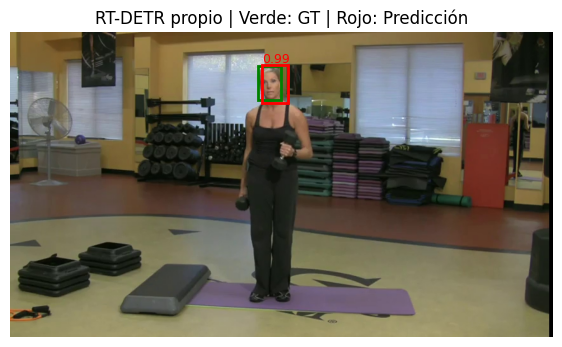

In [ ]:
visualize_rtdetr_prediction(
    model=rtdetr_model,
    dataset=val_ds,
    index=10,
    score_threshold=0.5
)
